In [32]:
# Setup for Kaggle or Google Colab environments
# Run this cell to install any missing dependencies!
!pip install -q pandas numpy scikit-learn scipy matplotlib seaborn mplsoccer tqdm

# Player Style Clustering — Data Extraction & Exploratory Data Analysis

**Objective:** build a per-player profile of playing style from StatsBomb event data, to be used for K-Means clustering (Player Style Clustering). Unlike shot-level analysis, the unit of analysis here is **one player, aggregated over a season** — one row per player.

**Data scope:** three top European leagues, all fixed to season **2015/2016** — the only season where all three have a full 380-match schedule in the StatsBomb open data:

| Competition | `competition_id` | `season_id` |
|---|---|---|
| Premier League | 2 | 27 |
| La Liga | 11 | 27 |
| Serie A | 12 | 27 |

**Data source:** Kaggle dataset `saurabhshahane/statsbomb-football-data`, located via the same auto-discovery approach used for shot-level extraction — it scans the input directory recursively and indexes files by structure rather than relying on exact nesting.

**Two computations that make this extraction different from a shot-level one:**
1. **Minutes played per player per match** — derived from `Starting XI`, `Substitution`, and red-card events — used as the denominator for every per-90 rate.
2. **Aggregation of many event types per player** (Pass, Shot, Dribble, Duel, Interception, Pressure, Clearance, Foul, ...), summed across every match played in the season.


## Setup

In [33]:
%matplotlib inline
import json
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

In [34]:
# Read from the local repo's data/ if present; otherwise (e.g. a bare Kaggle/Colab notebook)
# fall back to a writable working directory - /kaggle/input/... is read-only, so outputs
# can never be written there.
_LOCAL_DATA_DIR = next((p for p in [Path("../data"), Path("data"), Path("../../data")] if p.exists()), None)
if _LOCAL_DATA_DIR is not None:
    DATA_DIR = _LOCAL_DATA_DIR.resolve()
else:
    DATA_DIR = Path("/kaggle/working/data")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Using data directory:", DATA_DIR)

Using data directory: /kaggle/working/data


## Part A — Feature Extraction from Raw StatsBomb Events

This part builds `player_style_features_pl_laliga_seriea_1516.csv`: one row per player who played at least `MIN_MINUTES` minutes across the three leagues in 2015/2016.

Raw StatsBomb event JSON is not committed to this repo (`data/raw/` is gitignored). If it isn't found locally, extraction is skipped and the already-extracted CSV committed at `data/extract-feature/` is loaded instead — the notebook still runs end-to-end without the raw dataset.

In [35]:
COMPETITIONS = [
    (2, 27, "Premier League"),
    (11, 27, "La Liga"),
    (12, 27, "Serie A"),
]

MIN_MINUTES = 900  # keep players with >= 900 minutes (~10 full matches) across all 3 competitions combined
MAX_MATCHES_PER_COMPETITION = None  # set to a small number for a quick smoke test

RAW_CANDIDATES = [
    DATA_DIR / "raw",
    Path("/kaggle/input/datasets/saurabhshahane/statsbomb-football-data/data"),
]
RAW_DIR = next((p for p in RAW_CANDIDATES if p.exists() and any(p.rglob("*.json"))), None)

OUTPUT_CSV = DATA_DIR / "extract-feature" / "player_style_features_pl_laliga_seriea_1516.csv"

if RAW_DIR is None:
    print("Raw StatsBomb JSON not found locally - will skip extraction and load the pre-extracted CSV instead.")
else:
    print("Raw data found at:", RAW_DIR)

Raw data found at: /kaggle/input/datasets/saurabhshahane/statsbomb-football-data/data


### Auto-discovery of the dataset structure

Recursively scans `RAW_DIR` and indexes `competitions.json`, `matches/{competition_id}/{season_id}.json`, and `events/{match_id}.json`, regardless of nesting depth.

In [36]:
def discover_paths(base_dir: Path):
    competitions_path = None
    matches_index = {}
    events_index = {}

    for p in base_dir.rglob("*.json"):
        parts = p.parts
        if p.name == "competitions.json" and competitions_path is None:
            competitions_path = p
            continue
        if len(parts) >= 3 and parts[-3].lower() == "matches":
            competition_id, season_id = parts[-2], p.stem
            if competition_id.isdigit() and season_id.isdigit():
                matches_index[(int(competition_id), int(season_id))] = p
                continue
        if len(parts) >= 2 and parts[-2].lower() == "events":
            match_id = p.stem
            if match_id.isdigit():
                events_index[match_id] = p

    return competitions_path, matches_index, events_index


if RAW_DIR is not None:
    competitions_path, matches_index, events_index = discover_paths(RAW_DIR)
    print(f"competitions.json: {competitions_path}")
    print(f"Matches entries indexed: {len(matches_index)}")
    print(f"Events entries indexed: {len(events_index)}")
    for comp_id, season_id, label in COMPETITIONS:
        status = "OK" if (comp_id, season_id) in matches_index else "NOT FOUND"
        print(f"{label}: competition_id={comp_id}, season_id={season_id} -> {status}")

competitions.json: /kaggle/input/datasets/saurabhshahane/statsbomb-football-data/data/competitions.json
Matches entries indexed: 80
Events entries indexed: 4235
Premier League: competition_id=2, season_id=27 -> OK
La Liga: competition_id=11, season_id=27 -> OK
Serie A: competition_id=12, season_id=27 -> OK


In [37]:
def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def get_match_ids(competition_id, season_id):
    matches_path = matches_index.get((competition_id, season_id))
    if matches_path is None:
        raise FileNotFoundError(f"No matches file for ({competition_id}, {season_id})")
    return [m["match_id"] for m in load_json(matches_path)]


def get_events(match_id):
    events_path = events_index.get(str(match_id))
    if events_path is None:
        raise FileNotFoundError(f"No events file for match_id={match_id}")
    return load_json(events_path)

### Minutes played per player per match

Combines three end-of-involvement signals: `Substitution` (subbed off), a direct red card, or a second yellow card (`Foul Committed` / `Bad Behaviour` with `card.name` in `{"Red Card", "Second Yellow"}`). Players with none of these are assumed to have played until `match_end_minute` (read from the last `Half End` event).

**Known limitation (accepted):** a `Player Off` event without an accompanying `Substitution` (typically a temporary injury stoppage) is ignored — rare enough not to meaningfully bias a season-long per-90 aggregate.

In [38]:
RED_CARD_NAMES = {"Red Card", "Second Yellow"}


def compute_match_minutes(events):
    half_end_minutes = {}
    for e in events:
        if e["type"]["name"] == "Half End":
            p = e["period"]
            half_end_minutes[p] = max(half_end_minutes.get(p, 0), e["minute"])
    valid_periods = [p for p in half_end_minutes if p in (1, 2, 3, 4)]
    match_end_minute = max(half_end_minutes[p] for p in valid_periods) if valid_periods else 90

    start_minute = {}
    exit_minute = {}
    player_name = {}
    player_team = {}

    def register_exit(pid, minute):
        if pid not in exit_minute or minute < exit_minute[pid]:
            exit_minute[pid] = minute

    for e in events:
        etype = e["type"]["name"]

        if etype == "Starting XI":
            team = e["team"]["name"]
            for p in e.get("tactics", {}).get("lineup", []):
                pid = p["player"]["id"]
                start_minute[pid] = 0
                player_name[pid] = p["player"]["name"]
                player_team[pid] = team

        elif etype == "Substitution":
            off_id = e["player"]["id"]
            minute = e["minute"]
            register_exit(off_id, minute)
            replacement = e.get("substitution", {}).get("replacement")
            if replacement:
                on_id = replacement["id"]
                start_minute[on_id] = minute
                player_name[on_id] = replacement["name"]
                player_team[on_id] = e["team"]["name"]

        elif etype == "Foul Committed":
            card = e.get("foul_committed", {}).get("card", {}).get("name")
            if card in RED_CARD_NAMES:
                register_exit(e["player"]["id"], e["minute"])

        elif etype == "Bad Behaviour":
            card = e.get("bad_behaviour", {}).get("card", {}).get("name")
            if card in RED_CARD_NAMES:
                register_exit(e["player"]["id"], e["minute"])

    minutes_played = {}
    for pid, s in start_minute.items():
        end_ = exit_minute.get(pid, match_end_minute)
        minutes_played[pid] = max(0, end_ - s)

    return minutes_played, player_name, player_team

### Event aggregation per player

`TOUCH_EVENT_TYPES` is used for touches / average location / touches-in-box — only event types where the player is directly handling the ball (`Pressure` is excluded, since it represents acting on an opponent, not a touch).

In [39]:
TOUCH_EVENT_TYPES = {
    "Pass", "Shot", "Dribble", "Carry", "Ball Receipt*",
    "Miscontrol", "Clearance", "Interception", "Ball Recovery", "Goal Keeper",
}
TACKLE_SUCCESS_OUTCOMES = {"Won", "Success", "Success In Play", "Success Out"}
INTERCEPTION_SUCCESS_OUTCOMES = {"Won", "Success", "Success In Play", "Success Out"}


def scan_aerial_won(event):
    # Aerial duels can be nested inside several event types (Shot, Clearance, Duel, Miscontrol, ...)
    for v in event.values():
        if isinstance(v, dict) and v.get("aerial_won") is True:
            return True
    return False


def aggregate_match_events(events):
    stats_by_player = defaultdict(lambda: defaultdict(float))
    positions = defaultdict(Counter)

    for e in events:
        player = e.get("player")
        if not player:
            continue
        pid = player["id"]
        etype = e["type"]["name"]
        row = stats_by_player[pid]

        pos = e.get("position", {}).get("name")
        if pos:
            positions[pid][pos] += 1

        loc = e.get("location")
        if etype in TOUCH_EVENT_TYPES and loc:
            x, y = loc[0], loc[1]
            row["touches"] += 1
            row["sum_x"] += x
            row["sum_y"] += y
            row["sum_x2"] += x * x
            row["sum_y2"] += y * y
            if x >= 102 and 18 <= y <= 62:
                row["touches_in_box"] += 1

        if scan_aerial_won(e):
            row["aerial_won"] += 1

        if etype == "Shot":
            shot = e.get("shot", {})
            row["shots"] += 1
            if shot.get("outcome", {}).get("name") == "Goal" and shot.get("type", {}).get("name") != "Penalty":
                row["np_goals"] += 1
            if loc:
                dx, dy = 120 - loc[0], 40 - loc[1]
                row["sum_shot_distance"] += (dx ** 2 + dy ** 2) ** 0.5
                row["n_shots_with_distance"] += 1

        elif etype == "Dribble":
            row["dribbles"] += 1
            if e.get("dribble", {}).get("outcome", {}).get("name") == "Complete":
                row["dribbles_complete"] += 1

        elif etype == "Pass":
            passv = e.get("pass", {})
            row["passes"] += 1
            if "outcome" not in passv:
                row["passes_complete"] += 1
            if passv.get("shot_assist"):
                row["key_passes"] += 1
            if passv.get("goal_assist"):
                row["assists"] += 1
            if passv.get("cross"):
                row["crosses"] += 1
            if passv.get("technique", {}).get("name") == "Through Ball":
                row["through_balls"] += 1
            length = passv.get("length")
            if length is not None:
                row["sum_pass_length"] += length
                row["n_passes_with_length"] += 1
                if length > 30:
                    row["long_balls"] += 1

        elif etype == "Pressure":
            row["pressures"] += 1

        elif etype == "Duel":
            duel = e.get("duel", {})
            if duel.get("type", {}).get("name") == "Tackle":
                row["tackles"] += 1
                if duel.get("outcome", {}).get("name") in TACKLE_SUCCESS_OUTCOMES:
                    row["tackles_won"] += 1

        elif etype == "Interception":
            row["interceptions"] += 1
            outcome = e.get("interception", {}).get("outcome", {}).get("name")
            if outcome in INTERCEPTION_SUCCESS_OUTCOMES:
                row["interceptions_won"] += 1

        elif etype == "Ball Recovery":
            row["ball_recoveries"] += 1

        elif etype == "Clearance":
            row["clearances"] += 1

        elif etype == "Foul Committed":
            row["fouls_committed"] += 1

        elif etype == "Foul Won":
            row["fouls_won"] += 1

    return stats_by_player, positions

### Run extraction across all matches

In [40]:
if RAW_DIR is not None:
    global_minutes = defaultdict(float)
    global_matches_played = defaultdict(int)
    global_stats = defaultdict(lambda: defaultdict(float))
    global_positions = defaultdict(Counter)
    global_names = {}
    global_teams = defaultdict(Counter)
    global_competitions = defaultdict(set)
    failed_matches = []

    for comp_id, season_id, label in COMPETITIONS:
        match_ids = get_match_ids(comp_id, season_id)
        if MAX_MATCHES_PER_COMPETITION is not None:
            match_ids = match_ids[:MAX_MATCHES_PER_COMPETITION]
        print(f"{label}: {len(match_ids)} matches to process")

        for match_id in tqdm(match_ids, desc=label):
            try:
                events = get_events(match_id)
                minutes, names, teams = compute_match_minutes(events)
                match_stats, positions = aggregate_match_events(events)

                for pid, m in minutes.items():
                    if m <= 0:
                        continue
                    global_minutes[pid] += m
                    global_matches_played[pid] += 1
                    global_names[pid] = names[pid]
                    global_teams[pid][teams[pid]] += 1
                    global_competitions[pid].add(label)

                for pid, row in match_stats.items():
                    g_row = global_stats[pid]
                    for k, v in row.items():
                        g_row[k] += v

                for pid, counter in positions.items():
                    global_positions[pid].update(counter)

            except Exception as ex:
                print(f"[WARN] Error at match_id={match_id} ({label}): {ex}")
                failed_matches.append((label, match_id))

    print(f"\nTotal players with at least 1 minute played: {len(global_minutes)}")
    if failed_matches:
        print(f"Failed matches (skipped): {len(failed_matches)}")

Premier League: 380 matches to process


Premier League:   0%|          | 0/380 [00:00<?, ?it/s]

La Liga: 380 matches to process


La Liga:   0%|          | 0/380 [00:00<?, ?it/s]

Serie A: 380 matches to process


Serie A:   0%|          | 0/380 [00:00<?, ?it/s]


Total players with at least 1 minute played: 1622


### Build the per-90 feature table

In [41]:
if RAW_DIR is not None:
    rows = []
    for pid, minutes in global_minutes.items():
        row = global_stats[pid]
        factor = 90.0 / minutes if minutes > 0 else np.nan

        def rate(key):
            return row.get(key, 0.0) * factor

        def ratio(numer_key, denom_key):
            denom = row.get(denom_key, 0.0)
            return row.get(numer_key, 0.0) / denom if denom > 0 else np.nan

        def avg(sum_key, count_key):
            cnt = row.get(count_key, 0.0)
            return row.get(sum_key, 0.0) / cnt if cnt > 0 else np.nan

        touches = row.get("touches", 0.0)
        avg_x = row["sum_x"] / touches if touches > 0 else np.nan
        avg_y = row["sum_y"] / touches if touches > 0 else np.nan
        std_x = np.sqrt(max(row["sum_x2"] / touches - avg_x ** 2, 0)) if touches > 1 else np.nan
        std_y = np.sqrt(max(row["sum_y2"] / touches - avg_y ** 2, 0)) if touches > 1 else np.nan

        primary_team = global_teams[pid].most_common(1)[0][0] if global_teams[pid] else None
        primary_position = global_positions[pid].most_common(1)[0][0] if global_positions[pid] else None

        rows.append({
            "player_id": pid,
            "player_name": global_names.get(pid),
            "primary_team": primary_team,
            "competitions_played": ", ".join(sorted(global_competitions[pid])),
            "n_matches_played": global_matches_played[pid],
            "total_minutes_played": minutes,
            "shots_p90": rate("shots"),
            "np_goals_p90": rate("np_goals"),
            "avg_shot_distance": avg("sum_shot_distance", "n_shots_with_distance"),
            "dribbles_p90": rate("dribbles"),
            "dribble_success_rate": ratio("dribbles_complete", "dribbles"),
            "touches_p90": rate("touches"),
            "touches_in_box_p90": rate("touches_in_box"),
            "passes_p90": rate("passes"),
            "pass_completion_pct": ratio("passes_complete", "passes"),
            "key_passes_p90": rate("key_passes"),
            "assists_p90": rate("assists"),
            "crosses_p90": rate("crosses"),
            "through_balls_p90": rate("through_balls"),
            "long_balls_p90": rate("long_balls"),
            "avg_pass_length": avg("sum_pass_length", "n_passes_with_length"),
            "pressures_p90": rate("pressures"),
            "tackles_p90": rate("tackles"),
            "tackle_success_rate": ratio("tackles_won", "tackles"),
            "interceptions_p90": rate("interceptions"),
            "interception_success_rate": ratio("interceptions_won", "interceptions"),
            "ball_recoveries_p90": rate("ball_recoveries"),
            "clearances_p90": rate("clearances"),
            "aerial_won_p90": rate("aerial_won"),
            "fouls_committed_p90": rate("fouls_committed"),
            "fouls_won_p90": rate("fouls_won"),
            "avg_location_x": avg_x,
            "avg_location_y": avg_y,
            "std_location_x": std_x,
            "std_location_y": std_y,
            # Held out for cluster validation later - NOT used as a model feature
            "primary_position": primary_position,
        })

    player_df = pd.DataFrame(rows)
    player_df_filtered = player_df[player_df["total_minutes_played"] >= MIN_MINUTES].reset_index(drop=True)
    print(f"Players before filtering: {len(player_df)}")
    print(f"Players after filtering (>= {MIN_MINUTES} minutes): {len(player_df_filtered)}")

Players before filtering: 1622
Players after filtering (>= 900 minutes): 1016


### Sanity checks

In [42]:
if RAW_DIR is not None:
    print("Shape:", player_df_filtered.shape)
    display(player_df_filtered.head(3))

    missing = player_df_filtered.isna().sum()
    print(missing[missing > 0].sort_values(ascending=False))

    print(player_df_filtered["primary_position"].value_counts())
    print(player_df_filtered["competitions_played"].value_counts())

    # Sanity bound: at most 38 matches/competition, ~100 minutes/match including stoppage time
    max_possible_minutes = 38 * 100
    assert not (player_df_filtered["total_minutes_played"] > max_possible_minutes).any()
    assert not (player_df_filtered["total_minutes_played"] < 0).any()

Shape: (1016, 36)


,player_id,player_name,primary_team,competitions_played,n_matches_played,total_minutes_played,shots_p90,np_goals_p90,avg_shot_distance,dribbles_p90,...,ball_recoveries_p90,clearances_p90,aerial_won_p90,fouls_committed_p90,fouls_won_p90,avg_location_x,avg_location_y,std_location_x,std_location_y,primary_position
0,3339,Asmir Begović,Chelsea,Premier League,17,1472.0,0.000000,0.000000,NaN,0.000000,...,3.362772,0.000000,0.000000,0.000000,0.244565,9.588953,40.169961,6.030542,7.832626,Goalkeeper
1,5594,Branislav Ivanović,Chelsea,Premier League,33,3057.0,0.824338,0.058881,18.956525,0.529931,...,3.562316,3.856722,2.796860,1.148184,0.706575,60.060169,59.562310,27.428947,20.427508,Right Back
2,3456,Kurt Happy Zouma,Chelsea,Premier League,23,2013.0,0.715350,0.044709,16.912380,0.357675,...,2.369598,7.555887,3.979136,0.447094,0.402385,41.311802,52.834272,21.911993,12.956491,Right Center Back


avg_shot_distance            75
interception_success_rate    72
tackle_success_rate          70
dribble_success_rate         42
dtype: int64
primary_position
Right Center Back            94
Right Back                   91
Left Back                    88
Left Center Back             83
Center Forward               80
Goalkeeper                   73
Left Wing                    61
Right Wing                   60
Right Defensive Midfield     49
Right Center Midfield        48
Left Defensive Midfield      46
Center Attacking Midfield    42
Left Center Midfield         41
Center Defensive Midfield    39
Right Center Forward         27
Left Midfield                25
Right Midfield               22
Left Center Forward          19
Right Wing Back              11
Left Wing Back                9
Center Back                   7
Right Attacking Midfield      1
Name: count, dtype: int64
competitions_played
Serie A                    339
La Liga                    338
Premier League             327

### Save the extracted feature table

In [43]:
if RAW_DIR is not None:
    OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    player_df_filtered.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
    print(f"Saved: {OUTPUT_CSV} ({player_df_filtered.shape[0]} rows, {player_df_filtered.shape[1]} columns)")
else:
    print(f"Using the pre-extracted CSV already committed at: {OUTPUT_CSV}")

assert OUTPUT_CSV.exists(), (
    f"{OUTPUT_CSV} not found - raw StatsBomb data is missing locally and no pre-extracted CSV is committed either."
)

Saved: /kaggle/working/data/extract-feature/player_style_features_pl_laliga_seriea_1516.csv (1016 rows, 36 columns)


## Part B — Exploratory Data Analysis

**Input:** `player_style_features_pl_laliga_seriea_1516.csv` — 1016 players (Premier League + La Liga + Serie A, 2015/2016, filtered to >= 900 minutes played).

The unit of analysis is now **one player-season**, not one event, so the time-series techniques used for shot-level data (moving averages by minute, control charts by match) don't apply here. This EDA instead focuses on techniques suited to a multivariate player profile: distributions, dispersion, correlation/multicollinearity, and cross-checking against the true playing position (`primary_position`) before clustering.

In [44]:
df = pd.read_csv(OUTPUT_CSV, encoding="utf-8-sig")

FEATURE_COLS = [
    "shots_p90", "np_goals_p90", "avg_shot_distance", "dribbles_p90", "dribble_success_rate",
    "touches_p90", "touches_in_box_p90", "passes_p90", "pass_completion_pct", "key_passes_p90",
    "assists_p90", "crosses_p90", "through_balls_p90", "long_balls_p90", "avg_pass_length",
    "pressures_p90", "tackles_p90", "tackle_success_rate", "interceptions_p90",
    "interception_success_rate", "ball_recoveries_p90", "clearances_p90", "aerial_won_p90",
    "fouls_committed_p90", "fouls_won_p90", "avg_location_x", "avg_location_y",
    "std_location_x", "std_location_y",
]
print("Shape:", df.shape, "| numeric features:", len(FEATURE_COLS))

Shape: (1016, 36) | numeric features: 29


### Data overview

In [45]:
print("Shape:", df.shape)
df.head(3)

Shape: (1016, 36)


,player_id,player_name,primary_team,competitions_played,n_matches_played,total_minutes_played,shots_p90,np_goals_p90,avg_shot_distance,dribbles_p90,...,ball_recoveries_p90,clearances_p90,aerial_won_p90,fouls_committed_p90,fouls_won_p90,avg_location_x,avg_location_y,std_location_x,std_location_y,primary_position
0,3339,Asmir Begović,Chelsea,Premier League,17,1472.0,0.000000,0.000000,NaN,0.000000,...,3.362772,0.000000,0.000000,0.000000,0.244565,9.588953,40.169961,6.030542,7.832626,Goalkeeper
1,5594,Branislav Ivanović,Chelsea,Premier League,33,3057.0,0.824338,0.058881,18.956525,0.529931,...,3.562316,3.856722,2.796860,1.148184,0.706575,60.060169,59.562310,27.428947,20.427508,Right Back
2,3456,Kurt Happy Zouma,Chelsea,Premier League,23,2013.0,0.715350,0.044709,16.912380,0.357675,...,2.369598,7.555887,3.979136,0.447094,0.402385,41.311802,52.834272,21.911993,12.956491,Right Center Back


avg_shot_distance            75
interception_success_rate    72
tackle_success_rate          70
dribble_success_rate         42
dtype: int64


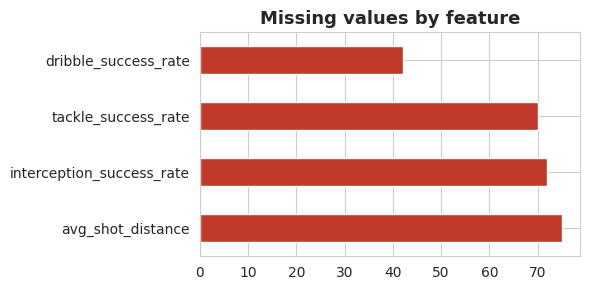

In [46]:
missing = df[FEATURE_COLS].isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

fig, ax = plt.subplots(figsize=(6, 3))
missing.plot(kind="barh", ax=ax, color="#c0392b")
ax.set_title("Missing values by feature")
plt.tight_layout()
plt.show()

These are all **conditional success-rate** columns (`dribble_success_rate`, `tackle_success_rate`, `interception_success_rate`) or a **conditional average** (`avg_shot_distance`) — `NaN` appears when a player never attempted that action all season (e.g. a goalkeeper has no `avg_shot_distance` because they never took a shot). This is structural missingness, not a data error, and needs dedicated handling in preprocessing rather than naive zero-imputation, since 0% success has a very different meaning from "never attempted".

### Position and team distribution

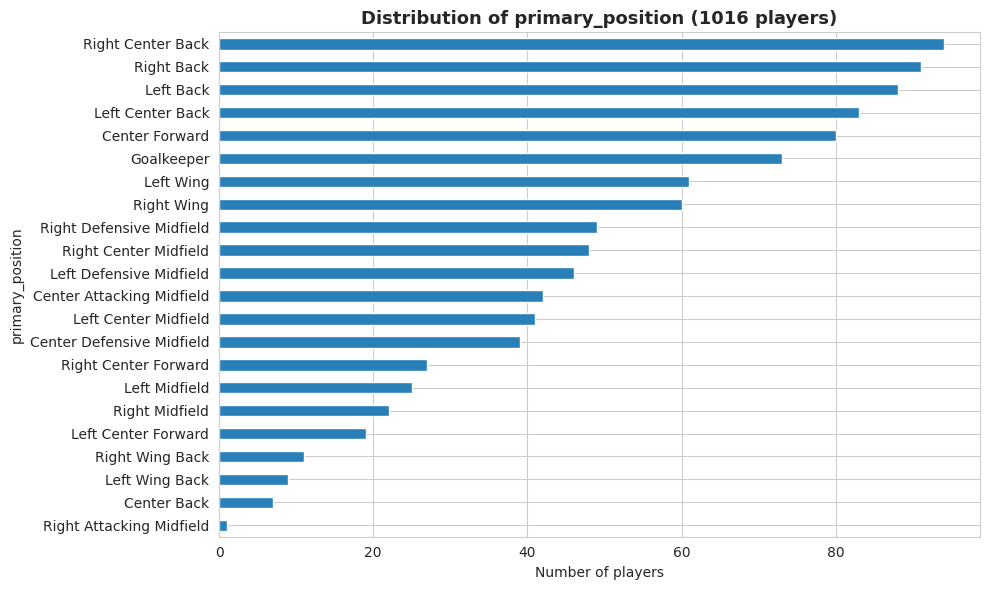

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))
df["primary_position"].value_counts().sort_values().plot(kind="barh", ax=ax, color="#2980b9")
ax.set_title(f"Distribution of primary_position ({len(df)} players)")
ax.set_xlabel("Number of players")
plt.tight_layout()
plt.show()

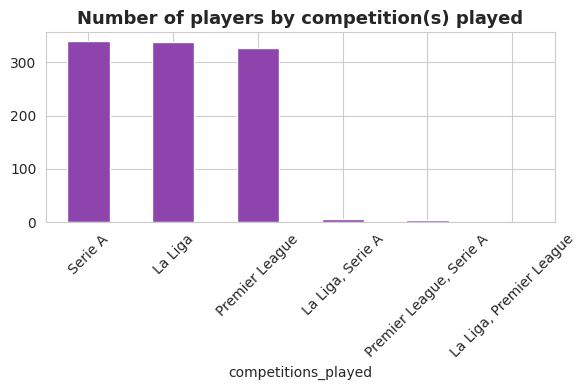

competitions_played
Serie A                    339
La Liga                    338
Premier League             327
La Liga, Serie A             6
Premier League, Serie A      5
La Liga, Premier League      1
Name: count, dtype: int64


In [48]:
fig, ax = plt.subplots(figsize=(6, 4))
df["competitions_played"].value_counts().plot(kind="bar", ax=ax, color="#8e44ad")
ax.set_title("Number of players by competition(s) played")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(df["competitions_played"].value_counts())

A small group of players (12/1016) appear in **two different competitions in the same season** — mid-season (winter) transfers. Their `primary_team` only reflects the club they appeared for most often, worth keeping in mind when interpreting results.

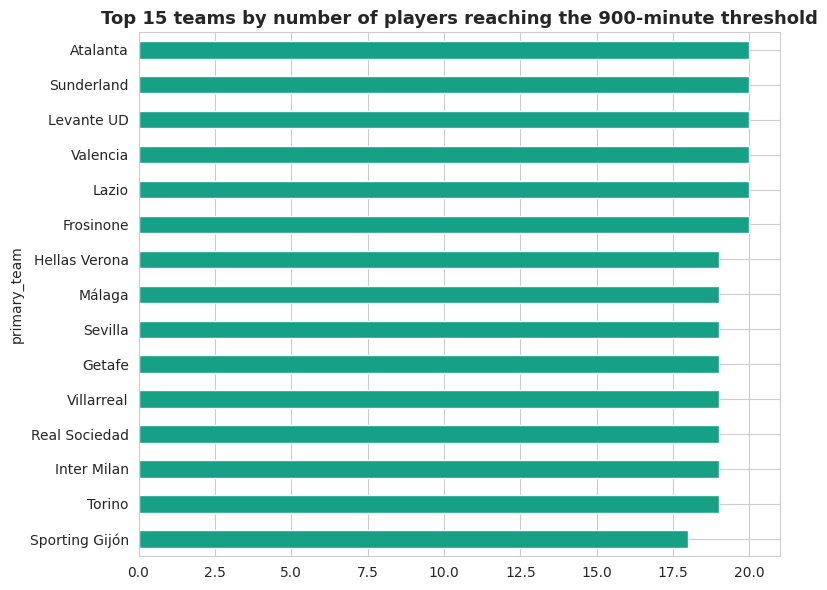

In [49]:
top_teams = df["primary_team"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_teams.sort_values().plot(kind="barh", ax=ax, color="#16a085")
ax.set_title("Top 15 teams by number of players reaching the 900-minute threshold")
plt.tight_layout()
plt.show()

### Distribution of key features

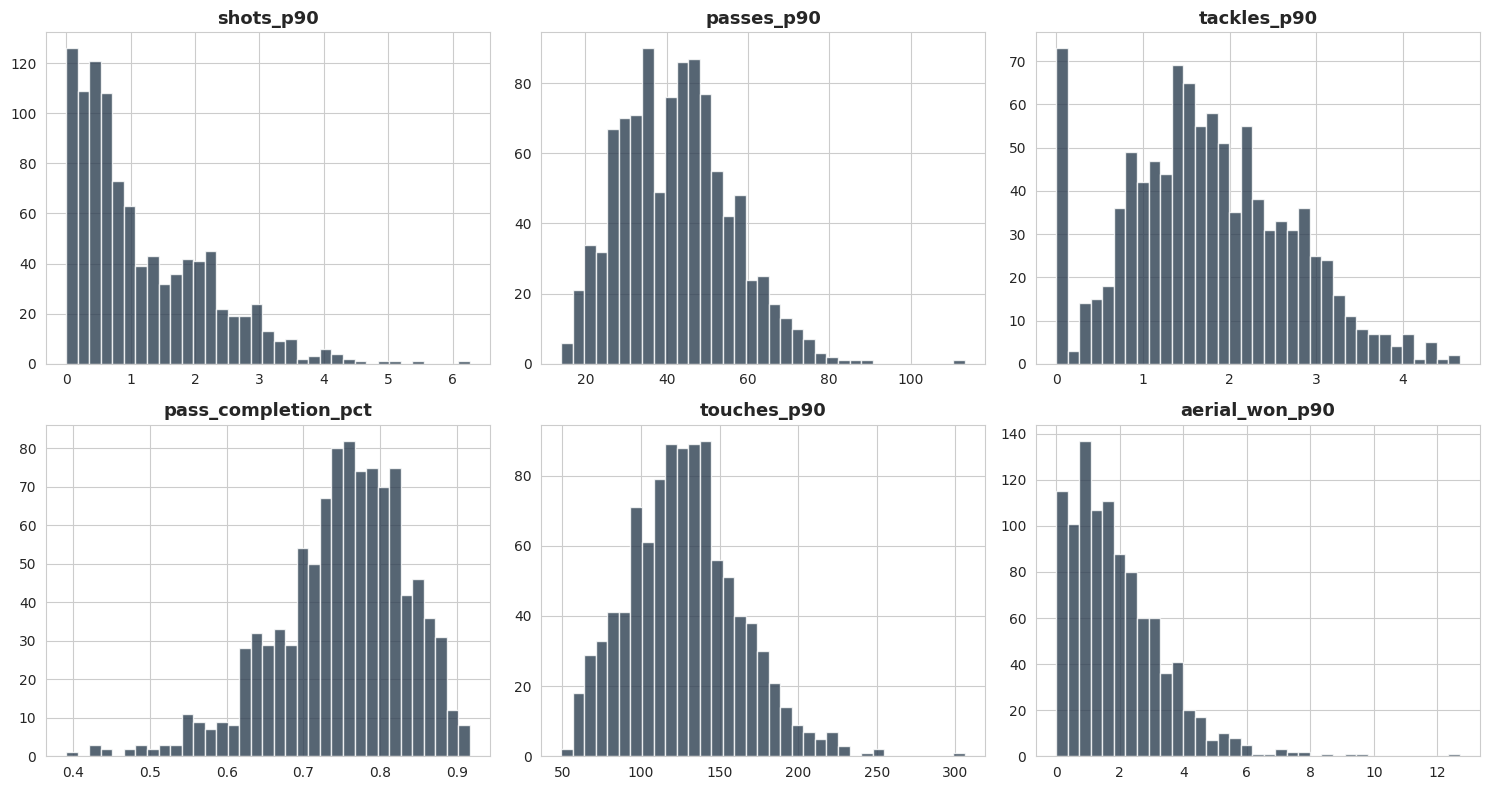

In [50]:
hist_cols = ["shots_p90", "passes_p90", "tackles_p90", "pass_completion_pct", "touches_p90", "aerial_won_p90"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, col in zip(axes, hist_cols):
    ax.hist(df[col].dropna(), bins=35, color="#2c3e50", alpha=0.8)
    ax.set_title(col)

plt.tight_layout()
plt.show()

`shots_p90` is strongly right-skewed (most players rarely shoot; a few forwards shoot a lot) — expected, since most of these 1016 players are defenders/defensive midfielders. `pass_completion_pct` is left-skewed (most players complete a high share of passes; only a few, often attackers attempting riskier passes, sit low). `tackles_p90` and `aerial_won_p90` both have a large mass near zero for attacking players who rarely engage in these actions.

### Descriptive statistics

In [51]:
pd.set_option("display.max_rows", 40)
df[FEATURE_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
shots_p90,1016.0,1.161645,1.015008,0.000000,0.391995,0.816236,1.834371,6.267563
np_goals_p90,1016.0,0.108074,0.147401,0.000000,0.000000,0.059308,0.149254,1.075697
avg_shot_distance,941.0,19.431573,5.422819,5.430624,15.445829,19.716188,23.411639,35.496486
dribbles_p90,1016.0,1.608351,1.416330,0.000000,0.501956,1.254014,2.316309,7.852349
dribble_success_rate,974.0,0.611360,0.177553,0.000000,0.500000,0.583333,0.700000,1.000000
touches_p90,1016.0,127.726316,35.303290,49.315417,103.117248,125.920892,148.568910,305.988004
touches_in_box_p90,1016.0,5.074682,5.248177,0.000000,1.470705,2.861987,7.435400,30.176307
passes_p90,1016.0,42.383093,13.541413,14.099695,31.954573,42.105778,50.787161,113.332223
pass_completion_pct,1016.0,0.750014,0.085231,0.390984,0.701870,0.759497,0.809751,0.916831
key_passes_p90,1016.0,0.746255,0.603563,0.000000,0.232489,0.665103,1.086324,3.542400


### Dispersion: standard deviation, variance, range, IQR

In [52]:
dispersion_rows = []
for col in FEATURE_COLS:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    dispersion_rows.append({
        "feature": col, "std": s.std(), "variance": s.var(),
        "range": s.max() - s.min(), "IQR": q3 - q1,
    })

dispersion_df = pd.DataFrame(dispersion_rows).set_index("feature")
dispersion_df

,std,variance,range,IQR
feature,,,,
shots_p90,1.015008,1.030242,6.267563,1.442376
np_goals_p90,0.147401,0.021727,1.075697,0.149254
avg_shot_distance,5.422819,29.406964,30.065861,7.965809
dribbles_p90,1.416330,2.005990,7.852349,1.814353
dribble_success_rate,0.177553,0.031525,1.000000,0.200000
touches_p90,35.303290,1246.322268,256.672587,45.451661
touches_in_box_p90,5.248177,27.543361,30.176307,5.964695
passes_p90,13.541413,183.369862,99.232528,18.832588
pass_completion_pct,0.085231,0.007264,0.525847,0.107881


Location features (`avg_location_x`, `avg_location_y`) have std/range measured in pitch meters (0-120 / 0-80), while success rates (`pass_completion_pct`, `tackle_success_rate`, ...) live in [0,1] — a large scale mismatch across features. This is direct evidence that **scaling is required** before feeding the data into K-Means.

### Box plots by playing position

An important preview: if per-90 features already separate cleanly by official playing position, that's a good sign K-Means (which has no knowledge of position) has a real chance of recovering similar structure.

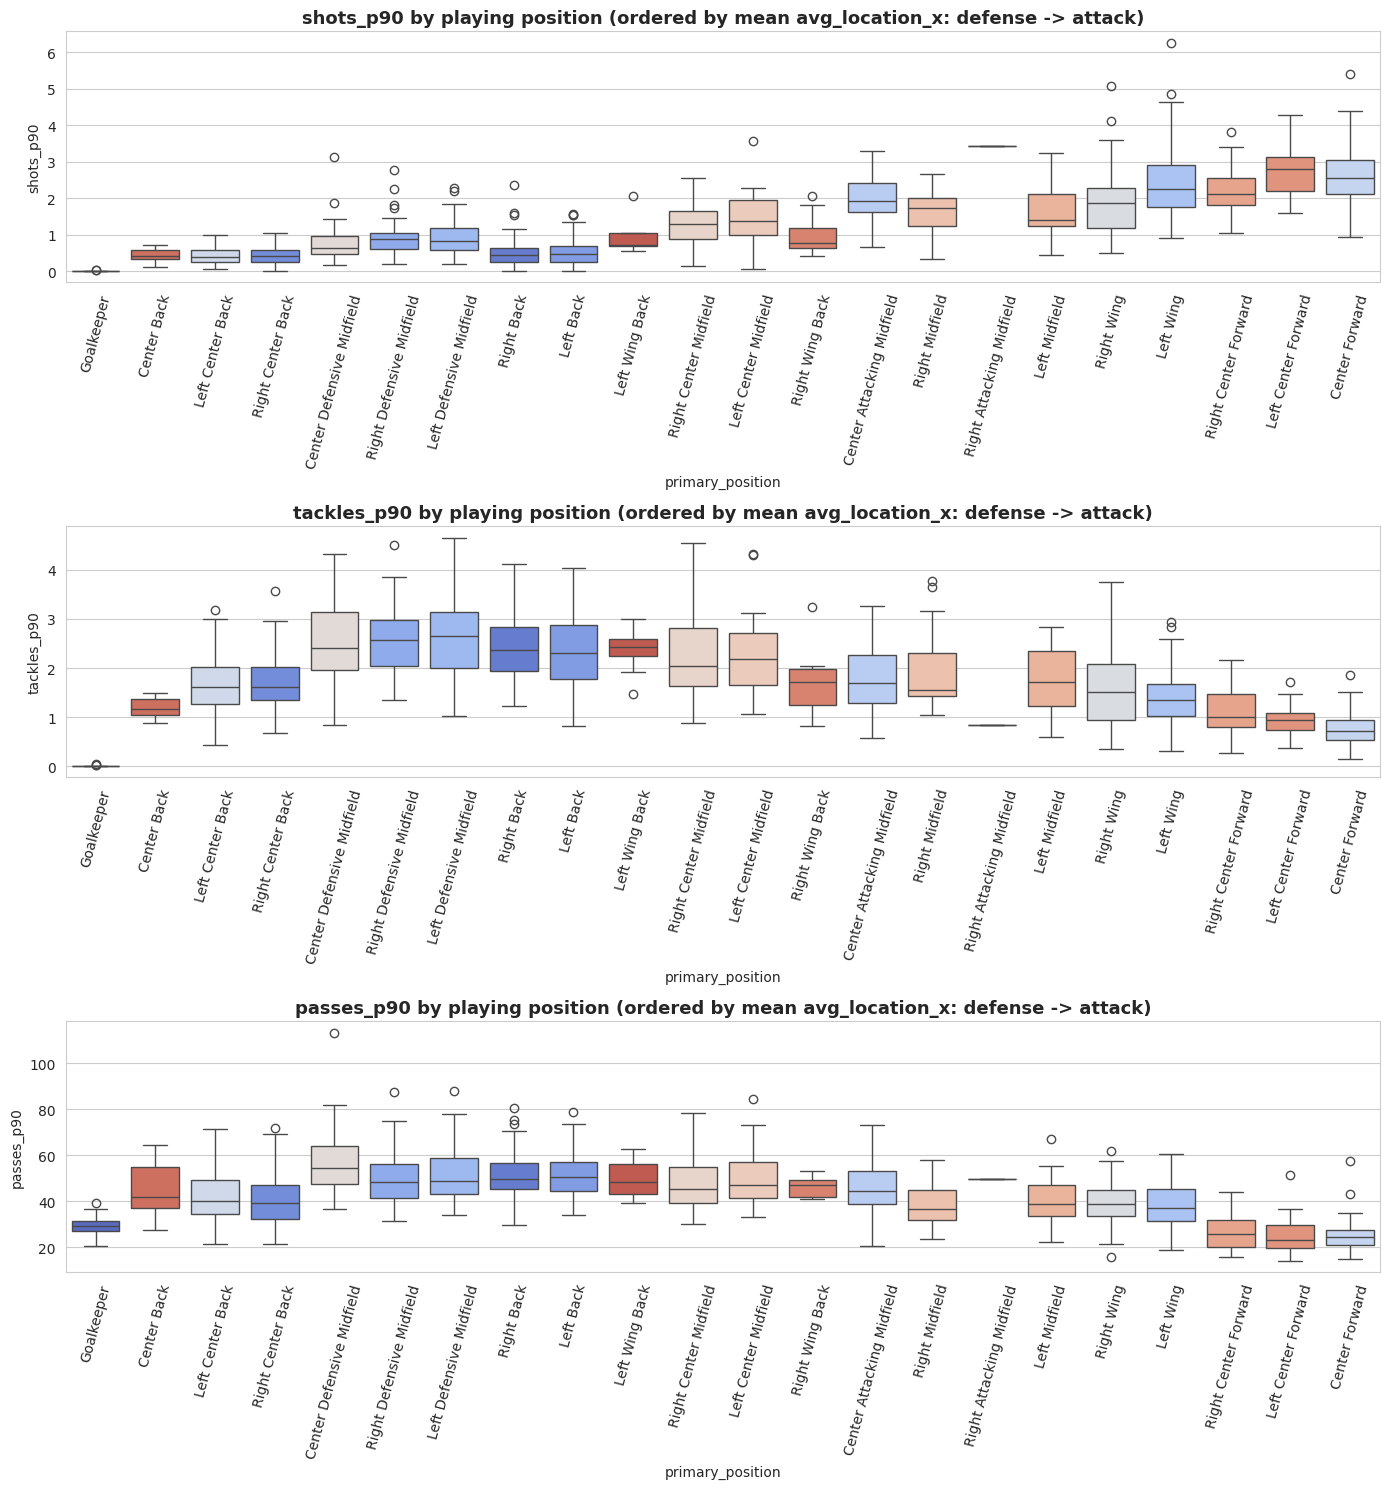

In [53]:
position_order = df.groupby("primary_position")["avg_location_x"].mean().sort_values().index

fig, axes = plt.subplots(3, 1, figsize=(14, 15))
for ax, col in zip(axes, ["shots_p90", "tackles_p90", "passes_p90"]):
    sns.boxplot(data=df, x="primary_position", y=col, order=position_order, ax=ax,
                hue="primary_position", palette="coolwarm", legend=False)
    ax.set_title(f"{col} by playing position (ordered by mean avg_location_x: defense -> attack)")
    ax.tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

`shots_p90` rises clearly from defensive to attacking positions, while `tackles_p90` trends the opposite way — matching football intuition. This confirms the extracted per-90 features genuinely carry position-discriminating information rather than noise, a reasonable basis for expecting K-Means to find meaningful cluster structure in the next step.

### Percentiles & z-scores: standout players

In [54]:
for col in ["shots_p90", "dribbles_p90", "tackles_p90"]:
    df[f"{col}_zscore"] = stats.zscore(df[col].fillna(df[col].mean()))

for col in ["shots_p90", "dribbles_p90", "tackles_p90"]:
    print(f"Top 5 players by {col} (highest z-score):")
    print(df.sort_values(f"{col}_zscore", ascending=False)[
        ["player_name", "primary_team", "primary_position", col]
    ].head(5))
    print()

Top 5 players by shots_p90 (highest z-score):
                             player_name primary_team primary_position  \
342  Cristiano Ronaldo dos Santos Aveiro  Real Madrid        Left Wing   
869              Gonzalo Gerardo Higuaín       Napoli   Center Forward   
676       Lionel Andrés Messi Cuccittini    Barcelona       Right Wing   
86             Philippe Coutinho Correia    Liverpool        Left Wing   
868                      Lorenzo Insigne       Napoli        Left Wing   

     shots_p90  
342   6.267563  
869   5.404157  
676   5.076758  
86    4.870795  
868   4.635635  

Top 5 players by dribbles_p90 (highest z-score):
                        player_name     primary_team      primary_position  \
672   Neymar da Silva Santos Junior        Barcelona             Left Wing   
676  Lionel Andrés Messi Cuccittini        Barcelona            Right Wing   
176                   Wilfried Zaha   Crystal Palace            Right Wing   
554       Yannick Ferreira Carrasco  Atlético

### Skewness & kurtosis

In [55]:
skew_kurt_rows = []
for col in FEATURE_COLS:
    s = df[col].dropna()
    skew_kurt_rows.append({
        "feature": col,
        "skewness": stats.skew(s),
        "kurtosis_excess": stats.kurtosis(s),
    })

skew_kurt_df = pd.DataFrame(skew_kurt_rows).set_index("feature").sort_values("skewness", ascending=False)
skew_kurt_df

,skewness,kurtosis_excess
feature,,
through_balls_p90,4.259456,41.076803
avg_pass_length,2.733410,7.731379
np_goals_p90,2.350533,7.898353
assists_p90,1.668237,3.440873
aerial_won_p90,1.523799,4.703398
touches_in_box_p90,1.418703,1.474850
crosses_p90,1.185224,1.094501
dribbles_p90,1.159761,1.149414
long_balls_p90,1.154917,1.781138


Attacking features that are rare for most players in this dataset (`through_balls_p90`, `assists_p90`, `crosses_p90`, `np_goals_p90`) have high skewness — expected, since most of the 1016 players are defenders/central midfielders, with only a minority of forwards/wingers producing high values. `pass_completion_pct` skews negative (a ceiling near 100%). This informs outlier handling in preprocessing: these extreme values should **not** be removed, since they are genuine style signals (high-output attackers), not noise.

### Value-range validation

In [56]:
rate_cols = ["dribble_success_rate", "pass_completion_pct", "tackle_success_rate", "interception_success_rate"]
for col in rate_cols:
    out_of_range = ~df[col].dropna().between(0, 1)
    print(f"{col}: {out_of_range.sum()} values outside [0,1]")

invalid_x = ~df["avg_location_x"].between(0, 120)
invalid_y = ~df["avg_location_y"].between(0, 80)
print(f"avg_location_x outside [0,120]: {invalid_x.sum()}")
print(f"avg_location_y outside [0,80]: {invalid_y.sum()}")

dribble_success_rate: 0 values outside [0,1]
pass_completion_pct: 0 values outside [0,1]
tackle_success_rate: 0 values outside [0,1]
interception_success_rate: 0 values outside [0,1]
avg_location_x outside [0,120]: 0
avg_location_y outside [0,80]: 0


### Correlation heatmap & multicollinearity

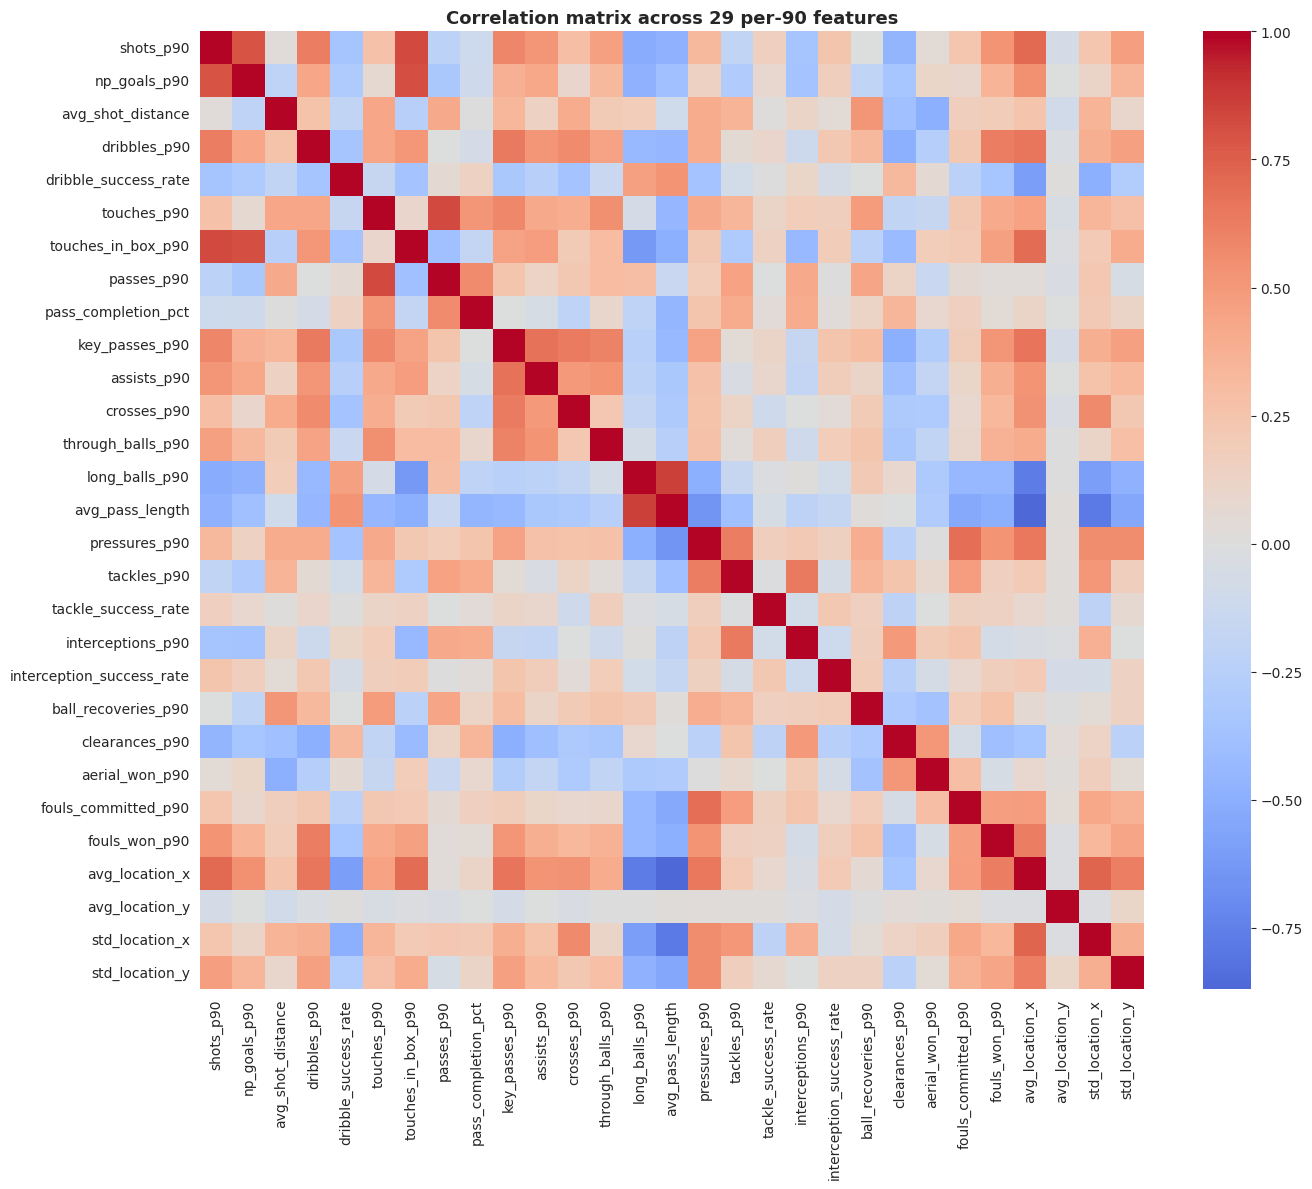

In [57]:
corr_matrix = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("Correlation matrix across 29 per-90 features")
plt.tight_layout()
plt.show()

In [58]:
pairs = []
cols = FEATURE_COLS
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.75:
            pairs.append((cols[i], cols[j], round(r, 3)))
pairs.sort(key=lambda x: -abs(x[2]))
pd.DataFrame(pairs, columns=["feature_1", "feature_2", "correlation"])

,feature_1,feature_2,correlation
0,avg_pass_length,avg_location_x,-0.870
1,long_balls_p90,avg_pass_length,0.858
2,touches_p90,passes_p90,0.832
3,shots_p90,touches_in_box_p90,0.827
4,np_goals_p90,touches_in_box_p90,0.811
5,shots_p90,np_goals_p90,0.794
6,avg_pass_length,std_location_x,-0.778
7,long_balls_p90,avg_location_x,-0.772


No pair reaches near-total correlation (> 0.9). The strongest pair is `avg_pass_length` vs `avg_location_x` (r ≈ -0.87): defenders (low `avg_location_x`) tend to hit longer passes (clearances/line-breaking balls), while attackers (high `avg_location_x`) pass shorter — a real relationship between two different concepts (average position vs. passing technique), not redundant information, so **no feature needs to be dropped** before preprocessing. `touches_p90` vs `passes_p90` (r ≈ 0.83) is also notable (passing is a large subset of touches) but each still carries information the other doesn't (touches also include dribbles, carries, shots), so both are kept.

### Spatial check: average pitch location by position group

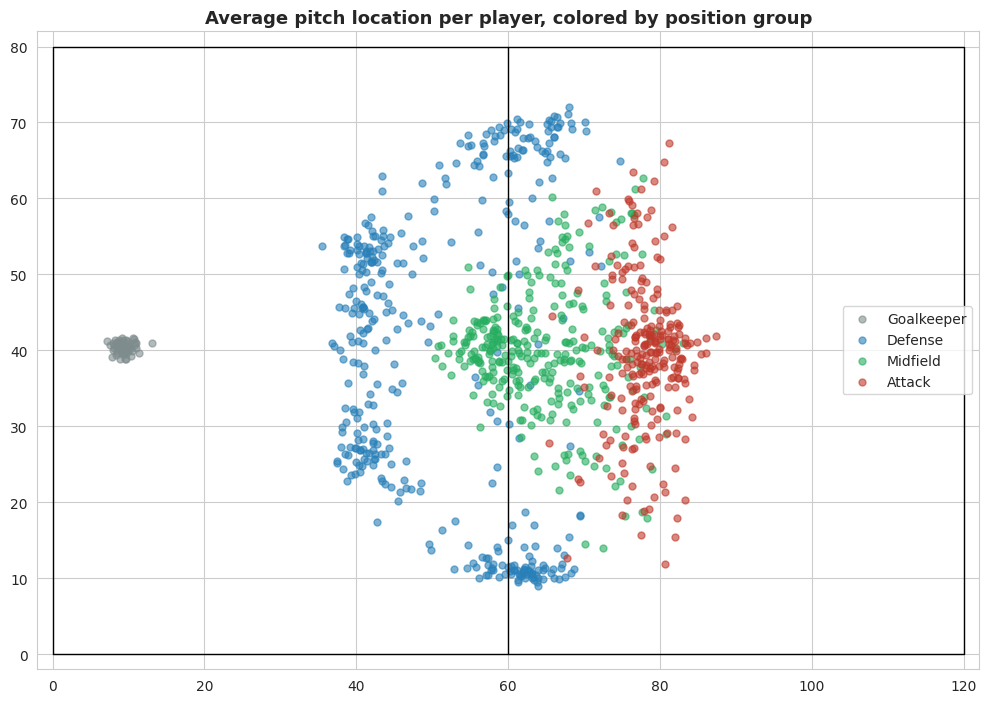

In [59]:
position_group_map = {
    "Goalkeeper": "Goalkeeper",
    "Center Back": "Defense", "Left Center Back": "Defense", "Right Center Back": "Defense",
    "Left Back": "Defense", "Right Back": "Defense",
    "Left Wing Back": "Defense", "Right Wing Back": "Defense",
    "Center Defensive Midfield": "Midfield", "Left Defensive Midfield": "Midfield", "Right Defensive Midfield": "Midfield",
    "Center Attacking Midfield": "Midfield", "Left Center Midfield": "Midfield", "Right Center Midfield": "Midfield",
    "Left Midfield": "Midfield", "Right Midfield": "Midfield", "Right Attacking Midfield": "Midfield",
    "Center Forward": "Attack", "Left Center Forward": "Attack", "Right Center Forward": "Attack",
    "Left Wing": "Attack", "Right Wing": "Attack",
}
df["position_group"] = df["primary_position"].map(position_group_map)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot([0, 0, 120, 120, 0], [0, 80, 80, 0, 0], color="black", linewidth=1)
ax.plot([60, 60], [0, 80], color="black", linewidth=1)

palette = {"Goalkeeper": "#7f8c8d", "Defense": "#2980b9", "Midfield": "#27ae60", "Attack": "#c0392b"}
for group, color in palette.items():
    sub = df[df["position_group"] == group]
    ax.scatter(sub["avg_location_x"], sub["avg_location_y"], s=25, alpha=0.6, color=color, label=group)

ax.set_xlim(-2, 122)
ax.set_ylim(-2, 82)
ax.set_aspect("equal")
ax.legend()
ax.set_title("Average pitch location per player, colored by position group")
plt.tight_layout()
plt.show()

A good sanity check: the four position groups separate into clearly distinct bands along the x-axis (Goalkeeper near x=0, then Defense, Midfield, Attack in increasing order) without any clustering algorithm — confirming `avg_location_x`/`avg_location_y` carry the expected spatial information.

### Correlation vs. regression

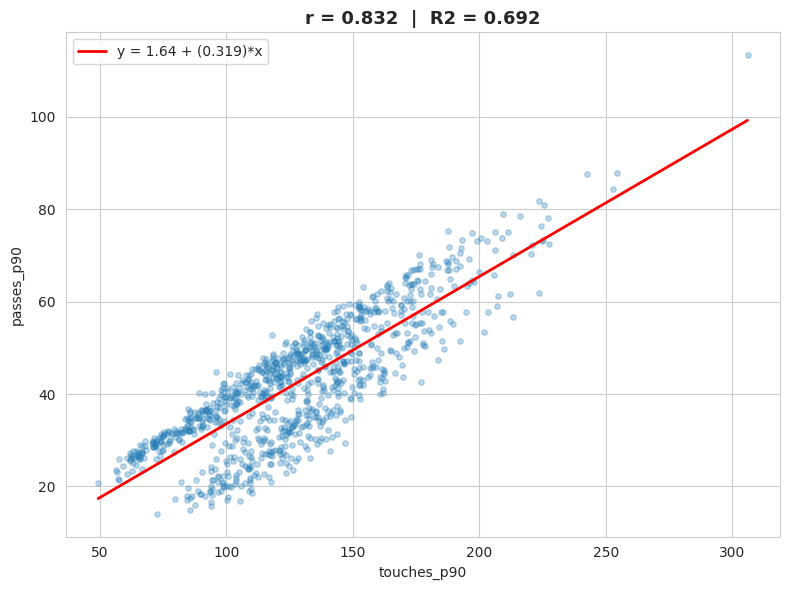

In [60]:
x = df["touches_p90"].values
y = df["passes_p90"].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, alpha=0.3, color="#2980b9", s=15)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, intercept + slope * x_line, color="red", linewidth=2,
        label=f"y = {intercept:.2f} + ({slope:.3f})*x")
ax.set_xlabel("touches_p90")
ax.set_ylabel("passes_p90")
ax.set_title(f"r = {r_value:.3f}  |  R2 = {r_value**2:.3f}")
ax.legend()
plt.tight_layout()
plt.show()

r ≈ 0.83 (R² ≈ 0.69) — about 69% of the variation in `passes_p90` is explained by `touches_p90`; the remaining ~31% comes from differing pass/touch ratios across positions (e.g. forwards touch the ball to dribble/shoot, not primarily to pass). The correlation coefficient only measures **the strength of a linear relationship**; the regression equation is the tool for **concrete prediction** — the same distinction discussed for the shot-level analysis.

### Correlation vs. causation: a confounding example

`aerial_won_p90` is a good illustration: looked at alone, without knowing playing position, it's easy to confuse two completely different types of player.

In [61]:
compare_positions = ["Right Center Back", "Left Center Back", "Center Forward"]
summary = df[df["primary_position"].isin(compare_positions)].groupby("primary_position")[
    ["aerial_won_p90", "pressures_p90", "avg_location_x"]
].mean()
summary

,aerial_won_p90,pressures_p90,avg_location_x
primary_position,,,
Center Forward,3.520772,14.223315,80.171352
Left Center Back,3.146723,9.259607,41.920340
Right Center Back,3.198113,9.343924,42.156508


Center backs (low `avg_location_x`) and center forwards (high `avg_location_x`) have **nearly identical** `aerial_won_p90` (~3.1-3.5), despite being opposite roles with very different areas of the pitch (`avg_location_x` far apart, `pressures_p90` about 50% higher for forwards). Judging these two positions as "similar" from `aerial_won_p90` alone would be wrong — the similar numbers only reflect that **both roles regularly contest aerial duels** (center backs clearing crosses, forwards competing for headed chances), not similar playing styles. This is why Player Style Clustering **must look at many features simultaneously** (combining `avg_location_x`, `pressures_p90`, etc.) rather than rely on any single indicator — the same "correlation ≠ causation" principle discussed for shot-level data.

### Summary: design decisions for preprocessing

In [62]:
summary_decisions = pd.DataFrame([
    {
        "Finding": "Features have very different scales (coordinates 0-120 vs. rates 0-1 vs. per-90 counts of a few units)",
        "Decision": "Test scaled vs. unscaled (Standard/RobustScaler)",
    },
    {
        "Finding": "No feature pair correlates above 0.9 (highest ~0.87, each pair still carries distinct meaning)",
        "Decision": "Keep all 29 features - no redundancy to remove",
    },
    {
        "Finding": "Missing values only occur in conditional success-rate / conditional-average columns (zero attempts) - structural, not an error",
        "Decision": "Do not impute with 0; impute with the column median instead",
    },
    {
        "Finding": "Box plots by primary_position show per-90 features already separate cleanly by position",
        "Decision": "Reasonable to expect K-Means to recover cluster structure close to true position/style",
    },
    {
        "Finding": "aerial_won_p90 alone cannot separate Center Back from Center Forward (confounded)",
        "Decision": "Clustering must be multivariate (many features at once), not based on 1-2 features",
    },
])
pd.set_option("display.max_colwidth", 100)
summary_decisions

,Finding,Decision
0,Features have very different scales (coordinates 0-120 vs. rates 0-1 vs. per-90 counts of a few ...,Test scaled vs. unscaled (Standard/RobustScaler)
1,"No feature pair correlates above 0.9 (highest ~0.87, each pair still carries distinct meaning)",Keep all 29 features - no redundancy to remove
2,Missing values only occur in conditional success-rate / conditional-average columns (zero attemp...,Do not impute with 0; impute with the column median instead
3,Box plots by primary_position show per-90 features already separate cleanly by position,Reasonable to expect K-Means to recover cluster structure close to true position/style
4,aerial_won_p90 alone cannot separate Center Back from Center Forward (confounded),"Clustering must be multivariate (many features at once), not based on 1-2 features"


## Results

`player_style_features_pl_laliga_seriea_1516.csv` (1016 players, 29 numeric features, `primary_position` held out for later validation) is now ready for preprocessing. Key EDA findings feeding into `02_modeling.ipynb`: features need scaling (very different units), all 29 features are worth keeping (no redundant pairs), missing values are structural and should be median-imputed rather than zero-filled, and clustering must be multivariate since no single feature reliably separates playing styles.